# Tarefa 1

Esta notebook executouse con google colab

Instalar e importar dependencias

In [11]:
!pip install torch torchvision transformers umap-learn pillow

In [12]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from transformers import ViTModel, ViTImageProcessor
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import umap
import os
from PIL import Image

# 1. Configuración e Carga

In [13]:
# Usar CUDA (colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando {device}")

Usando cuda


In [14]:
print("Cargando modelo ViT")

procesador = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTModel.from_pretrained('google/vit-base-patch16-224')
model.eval() # Modo avaliación

model.to(device)

Cargando modelo ViT


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ViTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (attention): ViTSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ViTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ViTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ViTOutput(
          (d

# 2. Preparación do Dataset (Tiny ImageNet)

In [15]:
from torch.utils.data import Subset

# Clonar o repositorio e acceder ao directorio de train
# ou usar o directorio se xa existe no sistema

if os.path.exists("./tiny-imagenet-200/"):
    print("Xa existe o directorio :)")
    train = "./tiny-imagenet-200/train/"
elif not os.path.exists("./IMagenet/"):
    print("Clonando Tiny ImageNet desde GitHub... :)")
    os.system("git clone https://github.com/seshuad/IMagenet.git")
    print("Clonado exitosamente")
    train = "./IMagenet/tiny-imagenet-200/train/"
else:
    train = "./IMagenet/tiny-imagenet-200/train/"

# Transformacións necesarias para ViT (Reseize a 224x224 e Normalización)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=procesador.image_mean, std=procesador.image_std)
])

# Definimos o dataset completo
full_dataset = datasets.ImageFolder(root=train, transform=transform)

n_images = 20
n_clases = 10

# Seleccionar as 20 imaxes de cada unha das 10 clases

indices = []
counts = {i: 0 for i in range(n_clases)}
for idx, (_, label) in enumerate(full_dataset.samples):
    if label < n_clases and counts[label] < n_images:
        indices.append(idx)
        counts[label] += 1

subset_dataset = Subset(full_dataset, indices)
dataloader = DataLoader(subset_dataset, batch_size=16, shuffle=False)

# 3. Extracción de Características (CLS Token)

In [16]:
features = []
labels = []

print(f"Extraendo características de {len(subset_dataset)} imaxes...")
with torch.no_grad():
    for imgs, target in dataloader:
        imgs = imgs.to(device)
        # O modelo devolve a última capa oculta
        outputs = model(imgs)
        # O CLS token é o primeiro token da secuencia (índice 0)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()

        features.append(cls_embeddings)
        labels.append(target.numpy())

features = np.concatenate(features, axis=0)
labels = np.concatenate(labels, axis=0)

Extraendo características de 200 imaxes...


# 4. Comparación Visual con UMAP (Gráfico bidimensional)

Calculando proxección UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


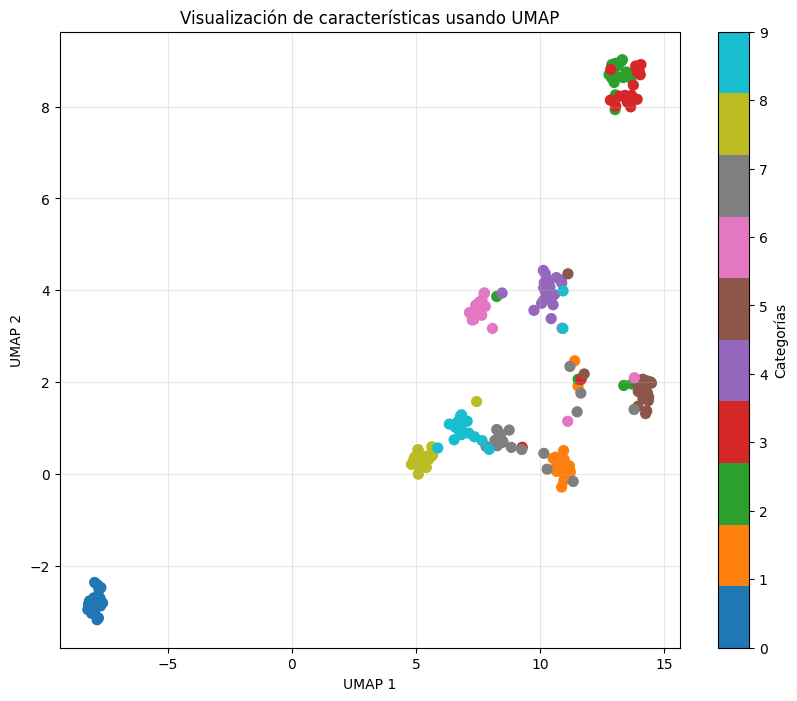

In [19]:
print("Calculando proxección UMAP...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='tab10', s=50)
plt.colorbar(scatter, ticks=range(n_clases), label='Categorías')
plt.title('Visualización de características usando UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)
plt.show()

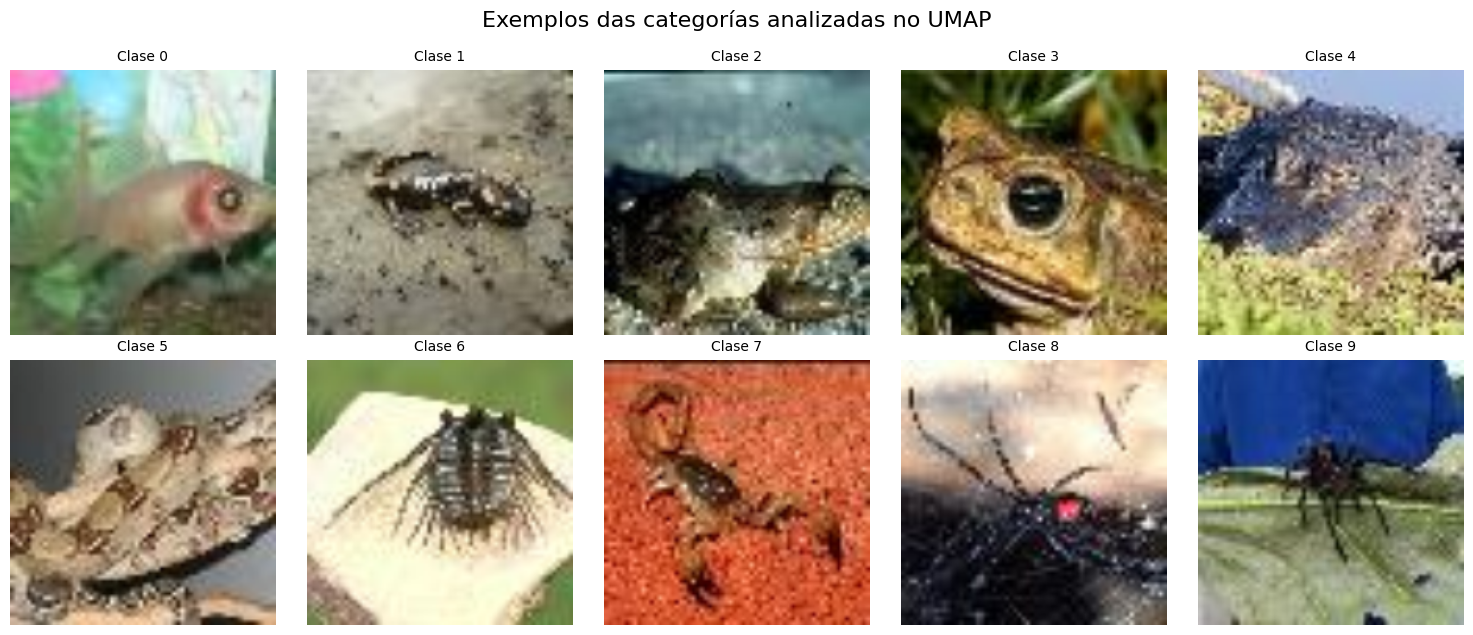

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# (words.txt)
class_names = {}
words_path = os.path.join(os.path.dirname(train.rstrip('/')), "../words.txt")

if os.path.exists(words_path):
    with open(words_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 2:
                class_names[parts[0]] = parts[1].split(',')[0] # Collemos o primeiro sinónimo

# unha imaxe de exemplo por cada clase no subset
example_images = []
example_labels = []

#  primeira imaxe de cada etiqueta do 0 ao 9
found_classes = set()
for i in range(len(subset_dataset)):
    img, label = subset_dataset[i]
    if label not in found_classes:
        example_images.append(img)
        example_labels.append(f"Clase {label}")
        found_classes.add(label)
    if len(found_classes) == n_clases:
        break

# 3. Mostrar as imaxes
plt.figure(figsize=(15, 6))
for i in range(len(example_images)):
    plt.subplot(2, 5, i + 1)

    # Des-normalizar a imaxe para que se vexa con cores naturais
    img = example_images[i].permute(1, 2, 0).numpy()
    img = (img * procesador.image_std) + procesador.image_mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(example_labels[i], fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Exemplos das categorías analizadas no UMAP", fontsize=16, y=1.05)
plt.show()

# Análisis dos resultados

- O illamento da Clase 0 (Goldfish):

No gráfico UMAP, a Clase 0 está completamente separada no extremo inferior esquerdo. Ningunha outra clase de "bichos" terrestres comparte paleta de cores nin composición, polo que o ViT xera un vector de características (CLS Token) moi único para ela.

-  O solapamento das Clases 2 e 3 (Rás/Sapos):

No UMAP, estas dúas clases están case pegadas no extremo superior dereito. O modelo identifica patróns visuais case idénticos, isto significa que ao buscar unha rá, é moi probable que o sistema tamén devolva sapos.

- Proximidade de Arácnidos e Insectos (Clases 7, 8 e 9):

Aínda que son especies distintas, comparten estruturas visuais similares (patas finas, corpos segmentados, fondos naturais).